In [2]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# !pip -q install kagglehub

In [1]:
import kagglehub

path = kagglehub.dataset_download("adityajn105/flickr8k")

print(path)

100%|██████████| 1.04G/1.04G [00:05<00:00, 199MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = PROJECT_DIR
except ImportError:
    PROJECT_DIR = str(ROOT)


Mounted at /content/drive


In [3]:
import os

print(os.listdir(path))

['Images', 'captions.txt']


In [4]:
image_dir = os.path.join(path, "Images")

print("Number of images:", len(os.listdir(image_dir)))

Number of images: 8091


In [5]:
import shutil
import os

drive_folder = os.path.join(PROJECT_DIR, "data/Flickr8k")

if os.path.exists(drive_folder):
    shutil.rmtree(drive_folder)

print("Deleted old copy.")


Deleted old copy.


In [6]:
import os
import shutil

project_dir = os.path.join(PROJECT_DIR, "data/Flickr8k")

os.makedirs("/content/drive/MyDrive/SOC_VLM/data", exist_ok=True)

shutil.copytree(path, project_dir, dirs_exist_ok=True)

print("Copied to:", project_dir)


Copied to: /content/drive/MyDrive/SOC_VLM/data/Flickr8k


In [7]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [8]:
captions_file = os.path.join(PROJECT_DIR, "data/Flickr8k/captions.txt")

with open(captions_file, "r", encoding="utf-8") as f:
    for _ in range(10):
        print(f.readline().strip())


image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .


In [9]:
import pandas as pd

captions_df = pd.read_csv(captions_file)

captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


# DATASET.PY



In [10]:
%%writefile dataset_obsolete_temp.py

import os
from collections import Counter

import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms


class Tokenizer:
    def __init__(self):
        self.vocab = {
            "<PAD>": 0,
            "<UNK>": 1,
            "<SOS>": 2,
        }
        self.inv_vocab = {}

    def build_vocab(self, captions):
        counter = Counter()

        for caption in captions:
            counter.update(caption.lower().split())

        for word in sorted(counter.keys()):
            self.vocab[word] = len(self.vocab)

        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def encode(self, text):
        tokens = [self.vocab["<SOS>"]]

        for word in text.lower().split():
            tokens.append(self.vocab.get(word, self.vocab["<UNK>"]))

        return tokens

    def decode(self, tokens):
        words = []

        for token in tokens:
            words.append(self.inv_vocab.get(token, "<UNK>"))

        return " ".join(words)

    def __len__(self):
        return len(self.vocab)

class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_df, tokenizer, transform=None):
        self.image_dir = image_dir
        self.captions_df = captions_df
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.captions_df)

    def __getitem__(self, idx):
        sample = self.captions_df.iloc[idx]

        image_name = sample["image"]
        caption = sample["caption"]

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        caption = self.tokenizer.encode(caption)

        return image, caption

def collate_fn(batch):
    images, captions = zip(*batch)

    images = torch.stack(images)

    max_len = max(len(caption) for caption in captions)

    padded_captions = []
    attention_masks = []

    for caption in captions:
        mask = [1] * len(caption) + [0] * (max_len - len(caption))
        padded = caption + [0] * (max_len - len(caption))

        padded_captions.append(padded)
        attention_masks.append(mask)

    captions = torch.tensor(padded_captions)
    attention_masks = torch.tensor(attention_masks)

    return images, captions, attention_masks


Overwriting /content/drive/MyDrive/SOC_VLM/dataset.py


In [11]:
import sys

PROJECT_DIR = PROJECT_DIR

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from project.tokenizers.word_tokenizer import WordTokenizer as Tokenizer

print("Imported successfully!")


Imported successfully!


In [12]:
import importlib
from project.datasets import flickr8k as dataset
importlib.reload(dataset)
from project.datasets.flickr8k import Flickr8kDataset


In [13]:
from project.datasets import flickr8k as dataset

print(dir(dataset))


['Counter', 'Dataset', 'Flickr8kDataset', 'Image', 'Tokenizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'collate_fn', 'os', 'pd', 'torch', 'transforms']


In [14]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

In [15]:
import random

# Get unique image names
image_names = sorted(captions_df["image"].unique())

print("Total images:", len(image_names))

random.seed(42)
random.shuffle(image_names)

train_images = set(image_names[:6000])
val_images   = set(image_names[6000:7000])
test_images  = set(image_names[7000:8000])

print(len(train_images), len(val_images), len(test_images))

Total images: 8091
6000 1000 1000


In [16]:
train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df   = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df  = captions_df[captions_df["image"].isin(test_images)].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

30000
5000
5000


In [17]:
tokenizer = Tokenizer()
tokenizer.build_vocab(captions_df['caption'])

train_dataset = Flickr8kDataset(
    image_dir=os.path.join(PROJECT_DIR, "data/Flickr8k/Images"),
    captions_df=train_df,
    tokenizer=tokenizer,
    transform=transform,
)

val_dataset = Flickr8kDataset(
    image_dir=os.path.join(PROJECT_DIR, "data/Flickr8k/Images"),
    captions_df=val_df,
    tokenizer=tokenizer,
    transform=transform,
)

test_dataset = Flickr8kDataset(
    image_dir=os.path.join(PROJECT_DIR, "data/Flickr8k/Images"),
    captions_df=test_df,
    tokenizer=tokenizer,
    transform=transform,
)


In [18]:
from torch.utils.data import DataLoader
from project.datasets.flickr8k import collate_fn

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)


In [19]:
import time

start = time.time()

for _ in train_loader:
    pass

end = time.time()

print(f"One epoch took {end-start:.2f} seconds")

One epoch took 187.13 seconds


In [20]:
for i in range(10):
    _, tokens = train_dataset[i]
    print(f"{i+1}. {tokenizer.decode(tokens)}")

1. <SOS> a child in a pink dress is climbing up a set of stairs in an entry way .
2. <SOS> a girl going into a wooden building .
3. <SOS> a little girl climbing into a wooden playhouse .
4. <SOS> a little girl climbing the stairs to her playhouse .
5. <SOS> a little girl in a pink dress going into a wooden cabin .
6. <SOS> a black dog and a spotted dog are fighting
7. <SOS> a black dog and a tri-colored dog playing with each other on the road .
8. <SOS> a black dog and a white dog with brown spots are staring at each other in the street .
9. <SOS> two dogs of different breeds looking at each other on the road .
10. <SOS> two dogs on pavement moving toward each other .


In [21]:
import os

data_dir = os.path.join(PROJECT_DIR, "data/Flickr8k")

print(os.listdir(data_dir))


['Images', 'captions.txt']


In [22]:
image, tokens = train_dataset[0]

print("Image shape :", image.shape)
print("Token length:", len(tokens))
print("Caption     :", tokenizer.decode(tokens))

Image shape : torch.Size([3, 64, 64])
Token length: 19
Caption     : <SOS> a child in a pink dress is climbing up a set of stairs in an entry way .


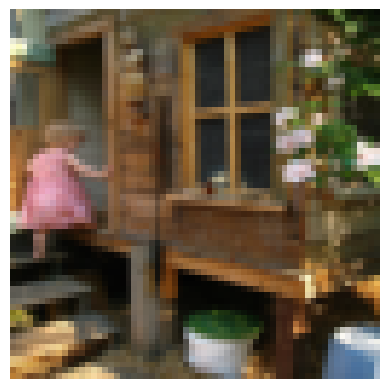

In [23]:
import torch
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

img = image * std + mean
img = img.permute(1,2,0).clamp(0,1)

plt.imshow(img)
plt.axis("off")
plt.show()

In [24]:
import importlib




from project.models.vit.vit_encoder import ViTEncoder
from project.models.clip.text_encoder import TextEncoder
from project.models.clip.clip_model import CLIPStyleModel


torch.Size([])
torch.Size([8, 128])
torch.Size([8, 128])
True
True
True
torch.Size([])
torch.Size([8, 128])
torch.Size([8, 128])
True
True
True


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

vit_encoder = ViTEncoder(
    img_size=64,
    patch_size=8,
    n_embd=192,
    n_head=6,
    n_layer=4,
    dropout=0.1,
)

text_encoder = TextEncoder(
    vocab_size=len(tokenizer),
    max_len=32,
    n_embd=192,
    n_head=6,
    n_layer=4,
)

model = CLIPStyleModel(
    vit_encoder=vit_encoder,
    text_encoder=text_encoder,
    embed_dim=192,
    projection_dim=128,
    init_temperature=0.07,
).to(device)

print("Model created successfully!")

Using device: cuda
Model created successfully!


In [26]:
images, captions, masks = next(iter(train_loader))

print(images.shape)
print(captions.shape)
print(masks.shape)

torch.Size([128, 3, 64, 64])
torch.Size([128, 24])
torch.Size([128, 24])


In [27]:
import inspect

print(inspect.signature(model.forward))

(images, text_tokens, text_mask=None)


In [30]:
outputs = model(
    images.to(device),
    captions.to(device),
    masks.to(device)
)

print(type(outputs))

if isinstance(outputs, tuple):
    print("Number of outputs:", len(outputs))
    for i, out in enumerate(outputs):
        if torch.is_tensor(out):
            print(f"Output {i}: {out.shape}")
        else:
            print(f"Output {i}: {type(out)}")

<class 'tuple'>
Number of outputs: 3
Output 0: torch.Size([])
Output 1: torch.Size([128, 128])
Output 2: torch.Size([128, 128])


In [31]:
loss, image_features, text_features = model(
    images.to(device),
    captions.to(device),
    masks.to(device)
)

print("Loss:", loss.item())
print(image_features.shape)
print(text_features.shape)

Loss: 5.051684856414795
torch.Size([128, 128])
torch.Size([128, 128])


In [43]:
%%writefile train_obsolete_temp.py


# ==========================================================
# CLIP Training Script
# Task 6 - VLM from Scratch
# ==========================================================

import os
import csv
import time
import random
import numpy as np
import pandas as pd

import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import (
    SequentialLR,
    LinearLR,
    CosineAnnealingLR,
)

import torchvision.transforms as transforms

from dataset import (
    Tokenizer,
    Flickr8kDataset,
    collate_fn,
)

from clip_model import (
    ViTEncoder,
    TextEncoder,
    CLIPStyleModel,
)


PROJECT_DIR = os.path.dirname(os.path.abspath(__file__))
os.chdir(PROJECT_DIR)

print("Working directory:", os.getcwd())
# ==========================================================
# Configuration
# ==========================================================

CONFIG = {

    "image_size":64,
    "max_text_len":32,

    "embed_dim":192,
    "projection_dim":128,
    "patch_size":8,
    "vit_depth":4,
    "text_depth":4,
    "n_head":6,
    "dropout":0.1,

    "batch_size":128,
    "epochs":20,

    "lr":5e-4,
    "weight_decay":0.05,

    "warmup_steps":500,
    "total_steps":10000,

    "grad_clip":1.0,

    "val_every":200,

    "seed":42,
}

# ==========================================================
# Reproducibility
# ==========================================================

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

torch.manual_seed(CONFIG["seed"])

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

# ==========================================================
# Device
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# ==========================================================
# Load Captions
# ==========================================================

captions_df = pd.read_csv(
    "data/Flickr8k/captions.txt"
)

print(f"Loaded {len(captions_df)} captions.")

# ==========================================================
# Tokenizer
# ==========================================================

tokenizer = Tokenizer()
tokenizer.build_vocab(captions_df["caption"])

print(f"Vocabulary size: {len(tokenizer)}")

# ==========================================================
# Image Transform
# ==========================================================

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ==========================================================
# Train / Val / Test Split
# ==========================================================

image_names = sorted(captions_df["image"].unique())

random.seed(CONFIG["seed"])
random.shuffle(image_names)

train_images = set(image_names[:6000])
val_images   = set(image_names[6000:7000])
test_images  = set(image_names[7000:8000])

train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df   = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df  = captions_df[captions_df["image"].isin(test_images)].reset_index(drop=True)

print(f"Train captions : {len(train_df)}")
print(f"Val captions   : {len(val_df)}")
print(f"Test captions  : {len(test_df)}")

# ==========================================================
# Dataset
# ==========================================================

image_dir = "data/Flickr8k/Images"

train_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_df=train_df,
    tokenizer=tokenizer,
    transform=transform,
)

val_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_df=val_df,
    tokenizer=tokenizer,
    transform=transform,
)

test_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_df=test_df,
    tokenizer=tokenizer,
    transform=transform,
)

# ==========================================================
# DataLoader
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

print("Data pipeline created successfully!")

batch = next(iter(train_loader))
images, captions, masks = batch

print(images.shape)
print(captions.shape)
print(masks.shape)

# ==========================================================
# Model
# ==========================================================

vit_encoder = ViTEncoder(
    img_size=CONFIG["image_size"],
    patch_size=CONFIG["patch_size"],
    n_embd=CONFIG["embed_dim"],
    n_head=CONFIG["n_head"],
    n_layer=CONFIG["vit_depth"],
    dropout=CONFIG["dropout"],
)

text_encoder = TextEncoder(
    vocab_size=len(tokenizer),
    max_len=CONFIG["max_text_len"],
    n_embd=CONFIG["embed_dim"],
    n_head=CONFIG["n_head"],
    n_layer=CONFIG["text_depth"],
)

model = CLIPStyleModel(
    vit_encoder=vit_encoder,
    text_encoder=text_encoder,
    embed_dim=CONFIG["embed_dim"],
    projection_dim=CONFIG["projection_dim"],
    init_temperature=0.07,
).to(device)

print("Model created successfully!")

# ==========================================================
# Optimizer
# ==========================================================

optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

print("Optimizer created.")

# ==========================================================
# Learning Rate Scheduler
# ==========================================================

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=CONFIG["warmup_steps"],
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["total_steps"] - CONFIG["warmup_steps"],
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[
        warmup_scheduler,
        cosine_scheduler,
    ],
    milestones=[
        CONFIG["warmup_steps"],
    ],
)

print("Scheduler created.")

# ==========================================================
# Forward Pass Verification
# ==========================================================

images, captions, masks = next(iter(train_loader))

images = images.to(device)
captions = captions.to(device)
masks = masks.to(device)

loss, image_features, text_features = model(
    images,
    captions,
    masks,
)

print("\nForward pass successful!")
print(f"Loss: {loss.item():.4f}")
print("Image features:", image_features.shape)
print("Text features :", text_features.shape)


Overwriting /content/drive/MyDrive/SOC_VLM/train.py


In [44]:
!python "$PROJECT_DIR/TASK 6/train.py"


torch.Size([])
torch.Size([8, 128])
torch.Size([8, 128])
True
True
True
Working directory: /content/drive/MyDrive/SOC_VLM
Using device: cuda
Loaded 40455 captions.
Vocabulary size: 8921
Train captions : 30000
Val captions   : 5000
Test captions  : 5000
Data pipeline created successfully!
torch.Size([128, 3, 64, 64])
torch.Size([128, 27])
torch.Size([128, 27])
Model created successfully!
Optimizer created.
Scheduler created.

Forward pass successful!
Loss: 5.0842
Image features: torch.Size([128, 128])
Text features : torch.Size([128, 128])
